# Outlier Treatment - java-ash-hysplit
Notebook ini menangani outlier pada fitur numerik menggunakan metode IQR capping (winsorization).

Kolom target untuk multi-output regression (`jarak_km`, `luas_km2`, `sudut_deg`, `radius_km`) **tidak diubah** agar label tetap asli.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
# Load dataset
DATA_PATH = Path(r'D:\Projects\volcanic_ash\modeling\java-ash-hysplit.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = [c.strip() for c in df_raw.columns]

print('Shape data awal:', df_raw.shape)
print('Kolom:', df_raw.columns.tolist())
display(df_raw.head(3))

Shape data awal: (1707, 16)
Kolom: ['id', 'timestamp', 'volcano_filter', 'alert_level', 'latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']


,id,timestamp,volcano_filter,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,jarak_km,luas_km2,sudut_deg,radius_km
0,1,2024-06-11 07:34:00 UTC,Merapi,Yellow,-7.54194,110.44194,2968,1000.0,4.7,270.0,50.0,30.0,32.511505,614.390650,303.257335,18.304149
1,2,2024-01-24 08:56:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1000.0,8.0,135.0,51.0,168.0,27.761756,460.792988,37.901873,15.892819
2,3,2023-03-15 03:36:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1200.0,7.1,90.0,65.0,133.0,44.625714,614.214150,265.635506,23.934437


In [3]:
# Konfigurasi penanganan outlier
TARGET_COLS = ['jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']
IQR_MULTIPLIER = 1.5

missing_targets = [c for c in TARGET_COLS if c not in df_raw.columns]
if missing_targets:
    raise KeyError(f'Target regresi tidak ditemukan: {missing_targets}')

# Outlier treatment hanya untuk fitur numerik (target tidak disentuh)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
excluded_from_treatment = set(TARGET_COLS + ['id'])
treat_cols = [c for c in numeric_cols if c not in excluded_from_treatment]

print('Kolom target (tidak diubah):', TARGET_COLS)
print('Kolom fitur yang ditangani outlier:', treat_cols)
print('Jumlah kolom treatment:', len(treat_cols))

Kolom target (tidak diubah): ['jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']
Kolom fitur yang ditangani outlier: ['latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration']
Jumlah kolom treatment: 8


In [4]:
def iqr_cap(series: pd.Series, multiplier: float = 1.5):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    # Jika IQR = 0, tidak dilakukan capping untuk menghindari over-correction
    if iqr == 0:
        return series.copy(), q1, q3, iqr, np.nan, np.nan, 0

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    capped = series.clip(lower=lower, upper=upper)
    replaced_count = int((capped != series).fillna(False).sum())
    return capped, q1, q3, iqr, lower, upper, replaced_count

In [5]:
# Terapkan outlier treatment ke fitur saja
df_clean = df_raw.copy()
report_rows = []

for col in treat_cols:
    capped, q1, q3, iqr, lower, upper, replaced_count = iqr_cap(df_raw[col], IQR_MULTIPLIER)

    if np.isnan(lower) or np.isnan(upper):
        outlier_before = 0
        outlier_after = 0
    else:
        outlier_before = int(((df_raw[col] < lower) | (df_raw[col] > upper)).fillna(False).sum())
        outlier_after = int(((capped < lower) | (capped > upper)).fillna(False).sum())

    df_clean[col] = capped

    report_rows.append({
        'column': col,
        'is_target': col in TARGET_COLS,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_before': outlier_before,
        'outlier_after': outlier_after,
        'replaced_count': replaced_count,
        'replaced_pct': round((replaced_count / len(df_raw)) * 100, 2)
    })

treatment_report = pd.DataFrame(report_rows)
if not treatment_report.empty:
    treatment_report = treatment_report.sort_values('replaced_pct', ascending=False).reset_index(drop=True)

display(treatment_report)

# Verifikasi bahwa target tetap identik
target_unchanged = all(df_clean[t].equals(df_raw[t]) for t in TARGET_COLS)
print('Target unchanged:', target_unchanged)

,column,is_target,q1,q3,iqr,lower_bound,upper_bound,outlier_before,outlier_after,replaced_count,replaced_pct
0,duration,False,107.00000,134.00000,27.00,66.500,174.500,112,0,112,6.56
1,tinggi_letusan_m,False,500.00000,800.00000,300.00,50.000,1250.000,99,0,99,5.80
2,kec_angin_km_jam,False,1.95000,6.10000,4.15,-4.275,12.325,28,0,28,1.64
3,latitude,False,-8.10805,-8.10805,0.00,NaN,NaN,0,0,0,0.00
4,longitude,False,112.92000,112.92000,0.00,NaN,NaN,0,0,0,0.00
5,elevation,False,3676.00000,3676.00000,0.00,NaN,NaN,0,0,0,0.00
6,arah_angin_deg,False,22.50000,225.00000,202.50,-281.250,528.750,0,0,0,0.00
7,amplitudo,False,22.00000,22.00000,0.00,NaN,NaN,0,0,0,0.00


Target unchanged: True


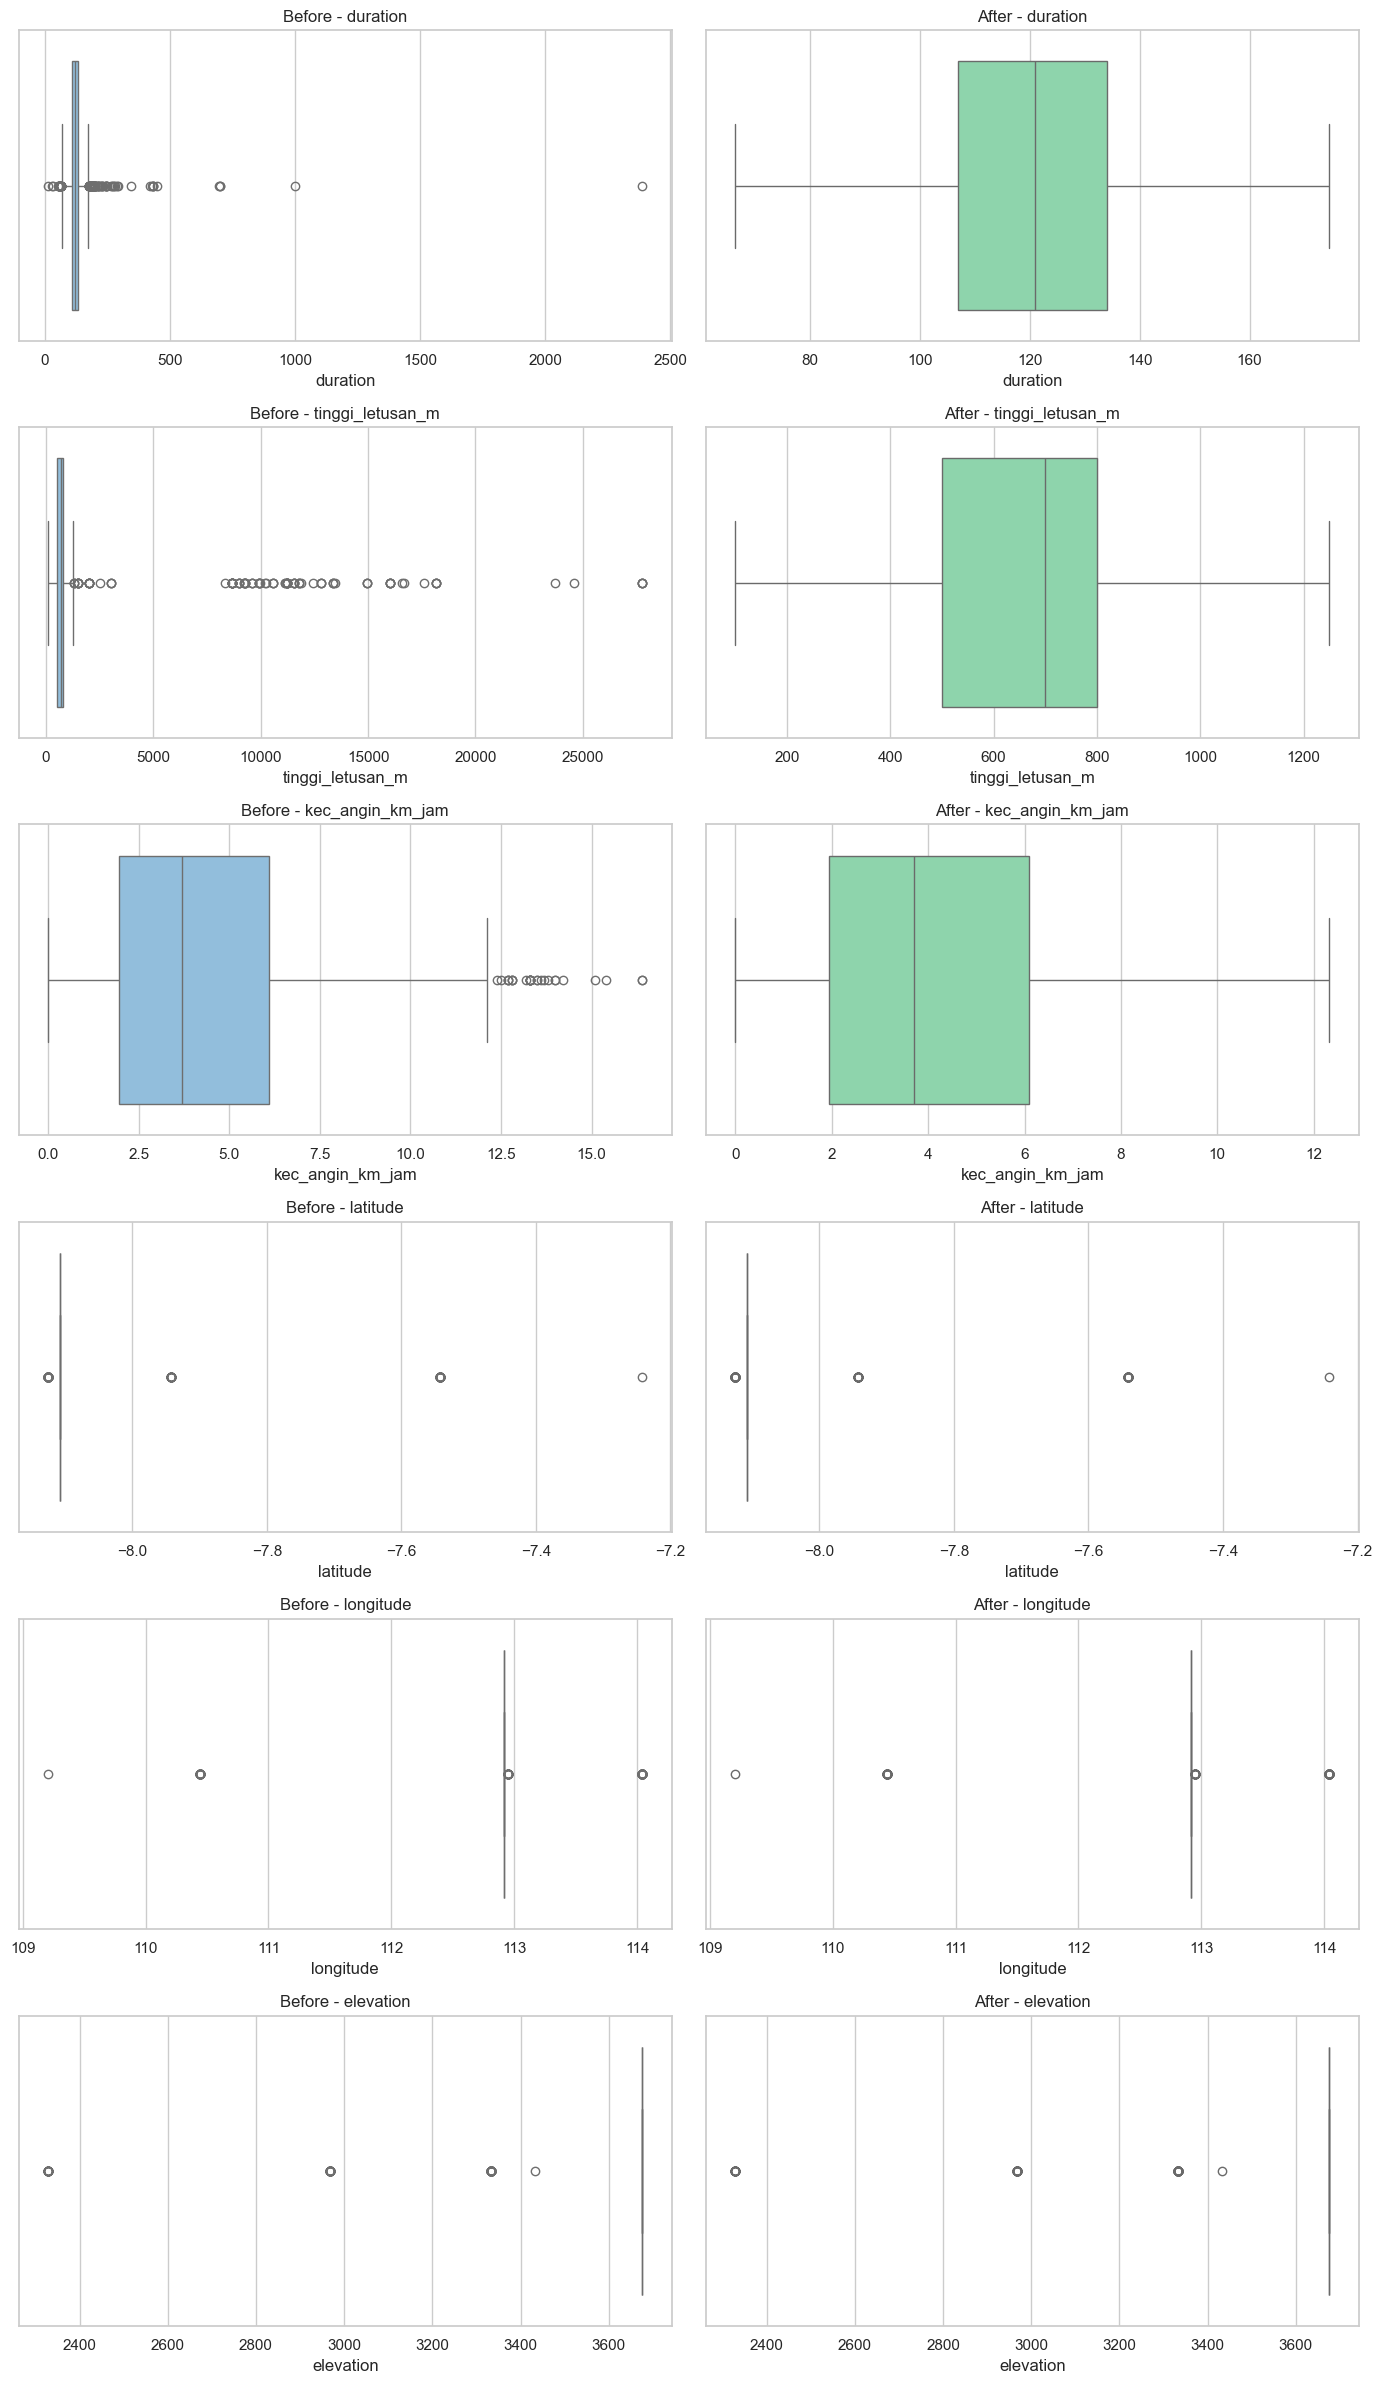

In [6]:
# Perbandingan distribusi fitur sebelum vs sesudah (top kolom dengan replacement terbesar)
if treatment_report.empty:
    print('Tidak ada kolom fitur yang diproses.')
else:
    top_cols = treatment_report.head(min(6, len(treatment_report)))['column'].tolist()

    fig, axes = plt.subplots(len(top_cols), 2, figsize=(14, 4 * len(top_cols)))
    if len(top_cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(top_cols):
        sns.boxplot(x=df_raw[col], ax=axes[i, 0], color='#85C1E9')
        axes[i, 0].set_title(f'Before - {col}')

        sns.boxplot(x=df_clean[col], ax=axes[i, 1], color='#82E0AA')
        axes[i, 1].set_title(f'After - {col}')

    plt.tight_layout()
    plt.show()

In [7]:
# Simpan hasil ke CSV baru
output_dir = DATA_PATH.parent / 'outlier_treatment_outputs'
output_dir.mkdir(parents=True, exist_ok=True)

clean_data_path = output_dir / 'java-ash-hysplit_outlier_handled.csv'
report_path = output_dir / 'outlier_treatment_report.csv'

# Pastikan urutan kolom tetap sama seperti data asli
df_clean = df_clean[df_raw.columns.tolist()]

# Validasi target tidak berubah
target_changes = {t: int((df_clean[t] != df_raw[t]).fillna(False).sum()) for t in TARGET_COLS}

# Simpan output
df_clean.to_csv(clean_data_path, index=False)
treatment_report.to_csv(report_path, index=False)

print('CSV hasil outlier treatment:', clean_data_path)
print('CSV report treatment      :', report_path)
print('Kolom tetap sama:', list(df_clean.columns) == list(df_raw.columns))
print('Perubahan pada target (harus 0):', target_changes)

CSV hasil outlier treatment: D:\Projects\volcanic_ash\modeling\outlier_treatment_outputs\java-ash-hysplit_outlier_handled.csv
CSV report treatment      : D:\Projects\volcanic_ash\modeling\outlier_treatment_outputs\outlier_treatment_report.csv
Kolom tetap sama: True
Perubahan pada target (harus 0): {'jarak_km': 0, 'luas_km2': 0, 'sudut_deg': 0, 'radius_km': 0}


## Catatan
- Metode yang dipakai adalah IQR capping, jadi nilai ekstrem tidak dibuang, tetapi dibatasi ke batas bawah/atas IQR.
- Dataset hasil tetap memiliki jumlah baris dan kolom yang sama dengan data asli.
- Kolom target untuk multi-regressor tetap asli (tidak diubah).
- Jika ingin lebih agresif, ubah `IQR_MULTIPLIER` ke nilai lebih kecil (misalnya 1.0).